# Prediction Market Directional Reliability
## What distinguishes markets that get the direction right from those that get it wrong?

Analysis of 110,000+ resolved prediction-market contracts across three platforms:
**Manifold** (play money), **Kalshi** (regulated US), and **Polymarket** (crypto).


## Setup

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)

print("Setup selesai.")
from scipy.stats import mannwhitneyu
from IPython.display import display


Setup selesai.


In [2]:
q_frames = []
for platform in ['manifold', 'kalshi', 'polymarket']:
    path = DATA / f'{platform}_questions.jsonl'
    if not path.exists():
        continue
    q_frames.append(pl.read_ndjson(path))

questions = pl.concat(q_frames, how='diagonal_relaxed')

df = (
    questions
    .filter(
        pl.col('outcome').is_in(['yes', 'no']) &
        pl.col('final_probability').is_not_null()
    )
    .with_columns([
        pl.when(pl.col('outcome') == 'yes').then(1).otherwise(0).alias('outcome_bin'),
        pl.col('final_probability').alias('p'),
    ])
    .with_columns(
        ((pl.col('p') - pl.col('outcome_bin')) ** 2).alias('brier')
    )
).to_pandas()

print(f"Total markets  : {len(df):,}")
for plat in ['manifold', 'kalshi', 'polymarket']:
    n = (df.platform == plat).sum()
    print(f"  {plat.capitalize():<12}: {n:,}")
print(f"Resolved YES   : {(df.outcome_bin==1).sum():,}  ({(df.outcome_bin==1).mean()*100:.1f}%)")
print(f"Resolved NO    : {(df.outcome_bin==0).sum():,}  ({(df.outcome_bin==0).mean()*100:.1f}%)")

Total markets  : 110,703
  Manifold    : 27,600
  Kalshi      : 12,000
  Polymarket  : 71,103
Resolved YES   : 36,968  (33.4%)
Resolved NO    : 73,735  (66.6%)


---
## Research Design

Each row in the dataset is one **resolved prediction-market contract**.
Key fields: `platform`, `title`, `final_probability` (p), `outcome` (yes/no), `category`.

**Two study groups:**

| Group | Definition |
|---|---|
| **Wrong direction** (cases) | p > 0.5 but outcome NO, or p < 0.5 but outcome YES |
| **Correct direction** (controls) | p > 0.5 and outcome YES, or p < 0.5 and outcome NO |

Markets with p = 0.5 are excluded — no directional consensus.

---
## Section I — Can the Crowd Actually Predict?

> Before asking *why* markets fail, we first need to know *how often* they fail at all.

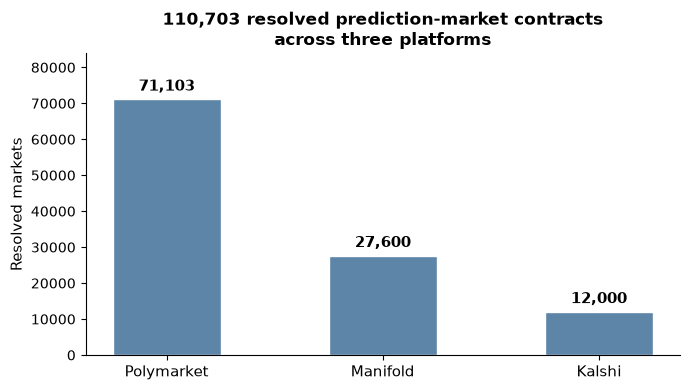

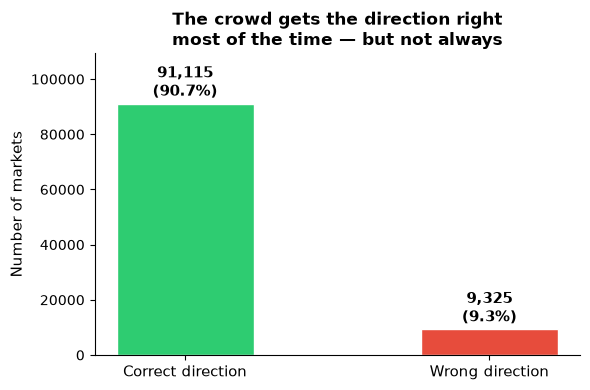


N = 100,440 markets with p ≠ 0.5
Wrong direction: 9,325 (9.3%)
Wilson 95% CI: [9.1%, 9.5%]


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
plat_counts = df['platform'].value_counts().sort_values(ascending=False)
bars = ax.bar(plat_counts.index.str.capitalize(), plat_counts.values,
              color='#5c85a8', edgecolor='white', width=0.5)
for bar, v in zip(bars, plat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + plat_counts.max() * 0.02,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Resolved markets', fontsize=11)
ax.set_title(f'{len(df):,} resolved prediction-market contracts\nacross three platforms',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, plat_counts.max() * 1.18)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig(FIGS / 'plot01_platforms.png', dpi=150, bbox_inches='tight')
plt.show()

_sub = df[df['p'] != 0.5].copy()
_sub['consensus_yes'] = _sub['p'] > 0.5
_sub['wrong']         = _sub['consensus_yes'] != (_sub['outcome_bin'] == 1)
n_total = len(_sub)
n_wrong = int(_sub['wrong'].sum())
n_right = n_total - n_wrong
pct_wr  = n_wrong / n_total * 100

from statsmodels.stats.proportion import proportion_confint
_lo, _hi = proportion_confint(n_wrong, n_total, method='wilson')

fig, ax = plt.subplots(figsize=(6, 4))
_bars = ax.bar(['Correct direction', 'Wrong direction'],
               [n_right, n_wrong],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.45)
for bar, v, pct in zip(_bars, [n_right, n_wrong], [100-pct_wr, pct_wr]):
    ax.text(bar.get_x() + bar.get_width()/2, v + n_total*0.01,
            f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_ylabel('Number of markets', fontsize=11)
ax.set_title('The crowd gets the direction right\nmost of the time — but not always',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(n_right, n_wrong) * 1.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig(FIGS / 'plot02_correct_wrong.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nN = {n_total:,} markets with p ≠ 0.5")
print(f"Wrong direction: {n_wrong:,} ({pct_wr:.1f}%)")
print(f"Wilson 95% CI: [{_lo*100:.1f}%, {_hi*100:.1f}%]")


The crowd is **generally** directionally informative — roughly 9 in 10 resolved
markets point the right way.

But this is an aggregate. The next question: are all markets equally reliable,
or do some fail far more often than others?

---
## Section II — Confidence Changes Everything

> If not all predictions are equally reliable, what predicts reliability?
> The most natural candidate: **how far the final probability is from 50%**.

Confidence is defined as |p − 0.5| — the distance of the final probability from the midpoint.

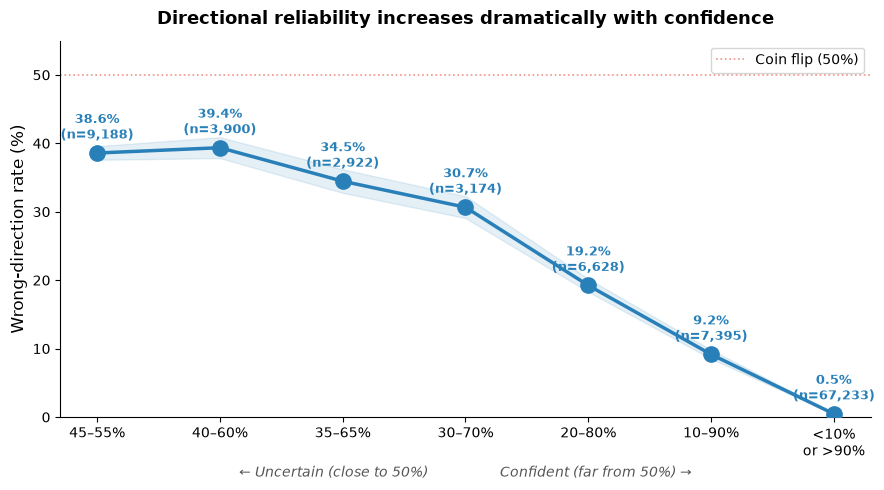

Wrong-direction rates by confidence bin:
  45–55%         38.6%  (n=9,188, 95% CI [37.6–39.6%])
  40–60%         39.4%  (n=3,900, 95% CI [37.8–40.9%])
  35–65%         34.5%  (n=2,922, 95% CI [32.8–36.2%])
  30–70%         30.7%  (n=3,174, 95% CI [29.1–32.3%])
  20–80%         19.2%  (n=6,628, 95% CI [18.3–20.2%])
  10–90%          9.2%  (n=7,395, 95% CI [8.5–9.8%])
  <10%            0.5%  (n=67,233, 95% CI [0.4–0.5%])


In [4]:
from statsmodels.stats.proportion import proportion_confint

_sub = df[df['p'] != 0.5].copy()
_sub['consensus_yes'] = _sub['p'] > 0.5
_sub['wrong']         = _sub['consensus_yes'] != (_sub['outcome_bin'] == 1)
_sub['conf']          = (_sub['p'] - 0.5).abs()

# 4 bins matching the guide: 45-55%, 30-70%, 10-90%, <10%/>90%
_bins   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
_labels = ['45–55%', '40–60%', '35–65%', '30–70%', '20–80%', '10–90%', '<10%\nor >90%']
_sub['cbin'] = pd.cut(_sub['conf'], bins=_bins, labels=_labels,
                      right=True, include_lowest=True)

_g = (_sub.groupby('cbin', observed=True)
          .agg(n=('wrong','count'), n_wr=('wrong','sum'))
          .reset_index())
_g['rate'] = _g['n_wr'] / _g['n']
_cis = [proportion_confint(r.n_wr, r.n, method='wilson') for _, r in _g.iterrows()]
_g['lo'] = [c[0] for c in _cis]
_g['hi'] = [c[1] for c in _cis]

fig, ax = plt.subplots(figsize=(9, 5))
_x = np.arange(len(_g))

ax.fill_between(_x, _g['lo']*100, _g['hi']*100, alpha=0.12, color='#2980b9')
ax.plot(_x, _g['rate']*100, 'o-', color='#2980b9', linewidth=2.5,
        markersize=11, zorder=4)
ax.axhline(50, color='#e74c3c', linewidth=1.2, linestyle=':',
           alpha=0.6, label='Coin flip (50%)')

ax.set_xticks(list(_x))
ax.set_xticklabels(_labels, fontsize=10)
ax.set_ylabel('Wrong-direction rate (%)', fontsize=12)
ax.set_xlabel('← Uncertain (close to 50%)                  Confident (far from 50%) →',
              fontsize=10, style='italic', color='#555')
ax.set_title('Directional reliability increases dramatically with confidence',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 55)

for xi, (_, row) in zip(_x, _g.iterrows()):
    ax.text(xi, row['rate']*100 + 1.5,
            f"{row['rate']*100:.1f}%\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2980b9')

ax.legend(fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / 'plot03_hero_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wrong-direction rates by confidence bin:")
for _, row in _g.iterrows():
    print(f"  {str(row['cbin']).split(chr(10))[0]:12s}  {row['rate']*100:5.1f}%  "
          f"(n={row['n']:,}, 95% CI [{row['lo']*100:.1f}–{row['hi']*100:.1f}%])")


This is the central finding of the notebook.

Directional reliability is **not uniform**. Markets with strong consensus (high confidence)
are almost always right. Markets near 50% fail close to half the time — barely better
than a coin flip.

The question is no longer *whether* prediction markets are informative, but *when*.

---
## Section III — Calibration Check

> Confidence (|p − 0.5|) is our key predictor. For that to be meaningful, the probabilities themselves must carry information — a market at 80% should resolve YES more often than one at 60%.

We verify this with a **reliability diagram** (observed outcome rate per probability bin) and **Brier Skill Score** (0% = coin flip, 100% = perfect). The goal is not a standalone finding — it validates that using confidence as a predictor in Sections II and V is well-founded.

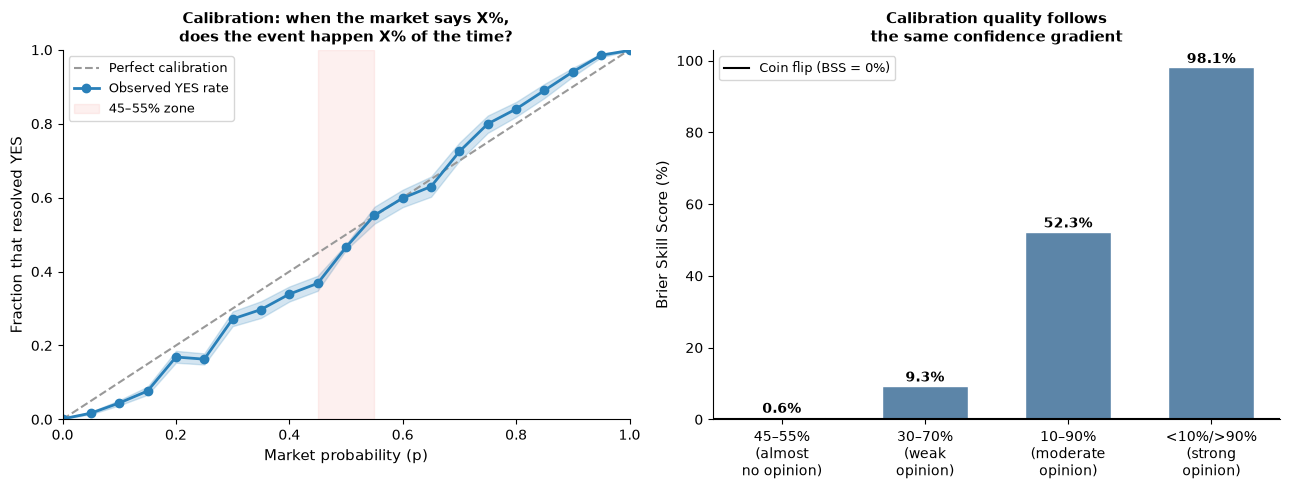

In [5]:
from statsmodels.stats.proportion import proportion_confint

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
_calib = df.copy()
_calib['pbin'] = ((_calib['p'] * 20).round() / 20).clip(0, 1)  # 5% bins
_cg = (_calib.groupby('pbin')
             .agg(n=('outcome_bin','count'), yes_rate=('outcome_bin','mean'))
             .reset_index())
_cg = _cg[_cg['n'] >= 50]
_cis = [proportion_confint(int(r.yes_rate * r.n), int(r.n), method='wilson')
        for _, r in _cg.iterrows()]
_cg['lo'] = [c[0] for c in _cis]
_cg['hi'] = [c[1] for c in _cis]

ax.plot([0, 1], [0, 1], '--', color='#999', linewidth=1.5, label='Perfect calibration')
ax.fill_between(_cg['pbin'], _cg['lo'], _cg['hi'], alpha=0.2, color='#2980b9')
ax.plot(_cg['pbin'], _cg['yes_rate'], 'o-', color='#2980b9', linewidth=2,
        markersize=6, label='Observed YES rate')
ax.axvspan(0.45, 0.55, alpha=0.08, color='#e74c3c', label='45–55% zone')
ax.set_xlabel('Market probability (p)', fontsize=11)
ax.set_ylabel('Fraction that resolved YES', fontsize=11)
ax.set_title('Calibration: when the market says X%,\ndoes the event happen X% of the time?',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
_bref = 0.25
_p = df['p'].values
_masks = [
    ((_p >= 0.45) & (_p <= 0.55), '45–55%\n(almost\nno opinion)', '#e74c3c'),
    (((_p >= 0.30) & (_p < 0.45)) | ((_p > 0.55) & (_p <= 0.70)),
     '30–70%\n(weak\nopinion)', '#e67e22'),
    (((_p >= 0.10) & (_p < 0.30)) | ((_p > 0.70) & (_p <= 0.90)),
     '10–90%\n(moderate\nopinion)', '#3498db'),
    ((_p < 0.10) | (_p > 0.90), '<10%/>90%\n(strong\nopinion)', '#27ae60'),
]
_bss_vals, _lbls = [], []
for mask, lbl, _clr in _masks:
    bss = (1 - df[mask]['brier'].mean() / _bref) * 100
    _bss_vals.append(bss); _lbls.append(lbl)

_bars = ax2.bar(range(4), _bss_vals, color='#5c85a8', edgecolor='white', width=0.6)
ax2.axhline(0, color='black', linewidth=1.5, label='Coin flip (BSS = 0%)')
ax2.set_xticks(range(4)); ax2.set_xticklabels(_lbls, fontsize=10)
ax2.set_ylabel('Brier Skill Score (%)', fontsize=11)
ax2.set_title('Calibration quality follows\nthe same confidence gradient',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
for bar, v in zip(_bars, _bss_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.3 if v >= 0 else -0.8),
             f'{v:.1f}%', ha='center',
             va='bottom' if v >= 0 else 'top',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS / 'plot04_calibration.png', dpi=150, bbox_inches='tight')
plt.show()


Markets are reasonably well-calibrated: probabilities spread across the full range and track outcomes. Confidence (|p − 0.5|) is a valid proxy for certainty — the foundation for the analysis in Section V.

---
## Section V — What Distinguishes Correct and Wrong Markets?

Confidence is the dominant signal. But across **all confidence levels**, are there other systematic characteristics — platform, volume, category, market duration, question wording — that further separate correct from wrong-direction markets?

In [6]:
from collections import Counter
from IPython.display import display

# ── Build study dataset from df (already loaded) ─────────────────────────────
# Add duration_sec if timestamps available in df
if 'resolved_at' in df.columns and 'created_at' in df.columns and 'duration_sec' not in df.columns:
    import pandas as _pd_ts
    df['duration_sec'] = (
        _pd_ts.to_datetime(df['resolved_at'], errors='coerce', utc=True) -
        _pd_ts.to_datetime(df['created_at'],  errors='coerce', utc=True)
    ).dt.total_seconds()

study = df[df['p'] != 0.5].copy()
study['consensus_yes'] = study['p'] > 0.5
study['salah']         = study['consensus_yes'] != (study['outcome_bin'] == 1)
study['conf']          = (study['p'] - 0.5).abs()

grp_salah = study[study['salah']]
grp_benar = study[~study['salah']]
n_salah, n_benar, n_total = len(grp_salah), len(grp_benar), len(study)

def fmt_p(p): return '<0.001' if p < 0.001 else f'{p:.3f}'

display(pd.DataFrame({
    'Group': ['Wrong direction (cases)', 'Correct direction (controls)', 'Total'],
    'N': [f'{n_salah:,}', f'{n_benar:,}', f'{n_total:,}'],
    'Share': [f'{n_salah/n_total*100:.1f}%', f'{n_benar/n_total*100:.1f}%', '100%'],
    'Definition': [
        'p > 0.5 and outcome NO, or p < 0.5 and outcome YES',
        'p > 0.5 and outcome YES, or p < 0.5 and outcome NO',
        'All markets with p ≠ 0.5',
    ],
}).style.hide(axis='index').set_caption('Study Groups (Case-Control Design)'))

Group,N,Share,Definition
Wrong direction (cases),"9,325",9.3%,"p > 0.5 and outcome NO, or p < 0.5 and outcome YES"
Correct direction (controls),"91,115",90.7%,"p > 0.5 and outcome YES, or p < 0.5 and outcome NO"
Total,"100,440",100%,All markets with p ≠ 0.5


### Characteristic 1 — Confidence

> Are wrong-direction markets simply less confident? We compare the full
> confidence distribution between the two groups across all confidence levels.

> **Question:** are correct-direction markets more confident than wrong ones?
> **Method:** Mann–Whitney U (one-sided) — confidence is heavily skewed, rank-based is more robust than t-test
> **Effect size:** rank-biserial r — ≈0.1 small · ≈0.3 medium · ≈0.5 large
> **Decision:** p < 0.05 → correct markets are indeed more confident · p ≥ 0.05 → confidence is indistinguishable

In [7]:
_r = grp_benar['conf'].dropna().values
_w = grp_salah['conf'].dropna().values

stat, p = mannwhitneyu(_r, _w, alternative='greater')
r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

display(pd.DataFrame([
    {'Group': 'Correct direction', 'n': len(_r), 'Median |p−0.5|': f'{np.median(_r):.3f}'},
    {'Group': 'Wrong direction',   'n': len(_w), 'Median |p−0.5|': f'{np.median(_w):.3f}'},
]).style.hide(axis='index').set_caption('Characteristic 1 — Confidence'))

print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median |p−0.5|
Correct direction,91115,0.490
Wrong direction,9325,0.085


Mann–Whitney U  p <0.001
Rank-biserial r = -0.806  (large effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Characteristic 2 — Number of Traders

> If wrong markets are simply less populated — attracting fewer participants
> so the consensus is less solid — then trader count should be lower in the wrong group.

> **Question:** do correct-direction markets attract more traders?
> **Method:** Mann–Whitney U (two-sided) — trader count is heavily right-skewed, rank-based is more appropriate
> **Decision:** p < 0.05 → systematic difference in participation · p ≥ 0.05 → trader count is not a differentiator

In [8]:
_r = grp_benar['num_traders'].dropna()
_w = grp_salah['num_traders'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Trader count data insufficient. Skipping.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Group': 'Correct direction', 'n': len(_r), 'Median traders': f'{np.median(_r):.0f}'},
        {'Group': 'Wrong direction',   'n': len(_w), 'Median traders': f'{np.median(_w):.0f}'},
    ]).style.hide(axis='index').set_caption('Characteristic 2 — Number of Traders'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
    print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median traders
Correct direction,24944,11
Wrong direction,2240,7


Mann–Whitney U  p <0.001
Rank-biserial r = -0.261  (small effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Characteristic 3 — Trading Volume

> Does financial commitment (or equivalent activity) distinguish correct
> from wrong markets? Higher volume could signal a more informationally efficient market —
> or simply a more popular one.

> **Question:** is trading volume higher in correct-direction markets?
> **Method:** Mann–Whitney U (two-sided) — volume is extreme across platforms (Manifold ~$0, Polymarket hundreds of thousands USD), rank-based analysis
> **Decision:** p < 0.05 → financial commitment is associated with accuracy · p ≥ 0.05 → volume is not a differentiator

In [9]:
_r = grp_benar['volume_usd'].dropna()
_w = grp_salah['volume_usd'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Volume data insufficient. Skipping.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Group': 'Correct direction', 'n': len(_r), 'Median volume (USD)': f'${np.median(_r):,.0f}'},
        {'Group': 'Wrong direction',   'n': len(_w), 'Median volume (USD)': f'${np.median(_w):,.0f}'},
    ]).style.hide(axis='index').set_caption('Characteristic 3 — Trading Volume'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
    print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median volume (USD)
Correct direction,79802,"$3,652"
Wrong direction,8852,"$2,687"


Mann–Whitney U  p <0.001
Rank-biserial r = -0.064  (small effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Characteristic 5 — Market Category

> Are wrong-direction markets concentrated in particular topic areas?
> We first test for a global association, then examine individual categories
> with multiple-testing correction.

> **Question:** are there topic categories that are consistently more wrong-direction?
> **Method:** Chi-square (global) + Binomial test per category with **BH FDR** correction
>
> **What is BH FDR?** We test ~20 categories simultaneously. By chance alone, roughly 1 in 20 would appear "significant" at α=0.05 — like rolling a die 20 times: you will get a six, that is not a signal. BH FDR controls the *proportion* of false positives among all significant results — a filter that separates signal from sampling luck.
>
> **Caveat:** a significant category means its *proportion* of wrong-direction markets differs — not that "markets in category X are wrong." A category with 45% wrong rate still produces 55% correct markets. Category is a probabilistic tendency, not a label.

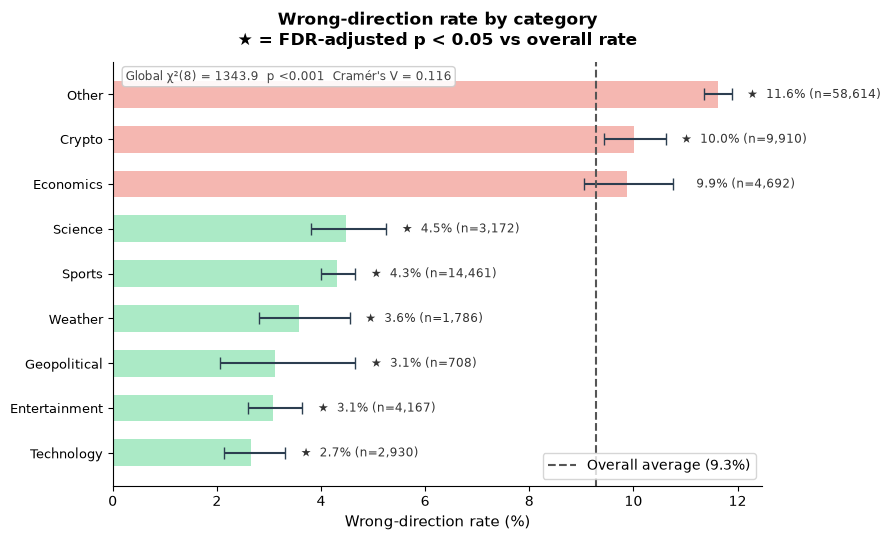

Global test: χ²(8) = 1343.90,  p <0.001,  Cramér's V = 0.1157
Significant categories after BH FDR: ['technology', 'entertainment', 'geopolitical', 'weather', 'sports', 'science', 'crypto', 'other']
Verdict: STATISTICALLY SUPPORTED DIFFERENCE — category is associated with error rate


In [10]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

_cat = study.dropna(subset=['category']).copy()
_cat['salah_int'] = _cat['salah'].astype(int)

# Global chi-square test: category × wrong_direction
_ct_global = pd.crosstab(_cat['category'], _cat['salah'])
if _ct_global.shape[1] == 2:
    _chi2_g, _p_g, _dof_g, _ = chi2_contingency(_ct_global)
    _n_g = _ct_global.values.sum()
    _cv_g = np.sqrt(_chi2_g / (_n_g * (min(_ct_global.shape) - 1)))
else:
    _p_g, _cv_g = 1.0, 0.0

# Per-category rates (min 30 markets)
_rates = (_cat.groupby('category', observed=True)
              .agg(n=('salah_int','count'), n_wr=('salah_int','sum'))
              .reset_index())
_rates = _rates[_rates['n'] >= 30].copy()
_cis = [proportion_confint(r.n_wr, r.n, method='wilson') for _, r in _rates.iterrows()]
_rates['rate'] = _rates['n_wr'] / _rates['n']
_rates['lo']   = [c[0] for c in _cis]
_rates['hi']   = [c[1] for c in _cis]
_rates = _rates.sort_values('rate', ascending=True).reset_index(drop=True)

# BH FDR correction on individual tests vs global rate
_p_global = study['salah'].mean()
from scipy.stats import binomtest
_pvals_ind = [binomtest(r.n_wr, r.n, _p_global).pvalue for _, r in _rates.iterrows()]
_, _p_adj, _, _ = multipletests(_pvals_ind, method='fdr_bh')
_rates['p_adj'] = _p_adj
_rates['sig']   = _p_adj < 0.05

fig, ax = plt.subplots(figsize=(9, max(4, len(_rates)*0.5 + 1)))
_y = np.arange(len(_rates))
_clrs = ['#e74c3c' if r > _p_global else '#2ecc71' for r in _rates['rate']]

ax.barh(_y, _rates['rate']*100, color=_clrs, alpha=0.4, height=0.6)
ax.errorbar(_rates['rate']*100, _y,
            xerr=[(_rates['rate']-_rates['lo'])*100, (_rates['hi']-_rates['rate'])*100],
            fmt='none', color='#2c3e50', capsize=4, linewidth=1.5)
for i, (_, row) in enumerate(_rates.iterrows()):
    ax.text(row['hi']*100 + 0.3, i,
            f"{'★' if row['sig'] else ''}  {row['rate']*100:.1f}% (n={row['n']:,})",
            va='center', fontsize=8.5, color='#333')

ax.axvline(_p_global*100, color='#555', linewidth=1.5, linestyle='--',
           label=f'Overall average ({_p_global*100:.1f}%)')
ax.set_yticks(_y)
ax.set_yticklabels(_rates['category'].str.capitalize(), fontsize=9)
ax.set_xlabel('Wrong-direction rate (%)', fontsize=11)
ax.set_title('Wrong-direction rate by category\n★ = FDR-adjusted p < 0.05 vs overall rate',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

_g_txt = (f"Global χ²({_dof_g}) = {_chi2_g:.1f}  "
          f"p {'<0.001' if _p_g < 0.001 else f'={_p_g:.3f}'}  "
          f"Cramér's V = {_cv_g:.3f}")
ax.text(0.02, 0.98, _g_txt, transform=ax.transAxes, fontsize=8.5,
        va='top', ha='left', color='#444',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))

plt.tight_layout()
plt.savefig(FIGS / 'plot11_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Global test: χ²({_dof_g}) = {_chi2_g:.2f},  "
      f"p {'<0.001' if _p_g < 0.001 else f'={_p_g:.4f}'},  Cramér's V = {_cv_g:.4f}")
_sig_cats = _rates[_rates['sig']]['category'].tolist()
if _sig_cats:
    print(f"Significant categories after BH FDR: {_sig_cats}")
else:
    print("No individual categories survive BH FDR correction at α=0.05")
if _p_g >= 0.05:
    print("Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE that category is "
          "associated with directional error")
else:
    print("Verdict: STATISTICALLY SUPPORTED DIFFERENCE — category is associated with error rate")


### Characteristic 6 — Title Keywords

> Do certain types of questions — as reflected in their title wording —
> appear disproportionately among wrong-direction markets?

This is **exploratory content analysis** — we systematically screen the entire vocabulary.

> **Question:** do certain words in market titles associate with wrong-direction outcomes?
> **Method:** Odds Ratio (OR) per word, BH FDR correction (same as Characteristic 5)
>
> **What is an Odds Ratio?**
> $$OR = \frac{\text{odds of wrong} | \text{word present}}{\text{odds of wrong} | \text{word absent}}$$
> OR = 2× means markets with that word are 2× more *likely* to be wrong than markets without it. But 2× of 10% = 20% — still more often correct. Like a smoker whose lung cancer risk is 15× higher — but most smokers never get lung cancer.
>
> ⚠️ *Observational — association, not causation. Words likely correlate with category or confidence, not direct causes.*

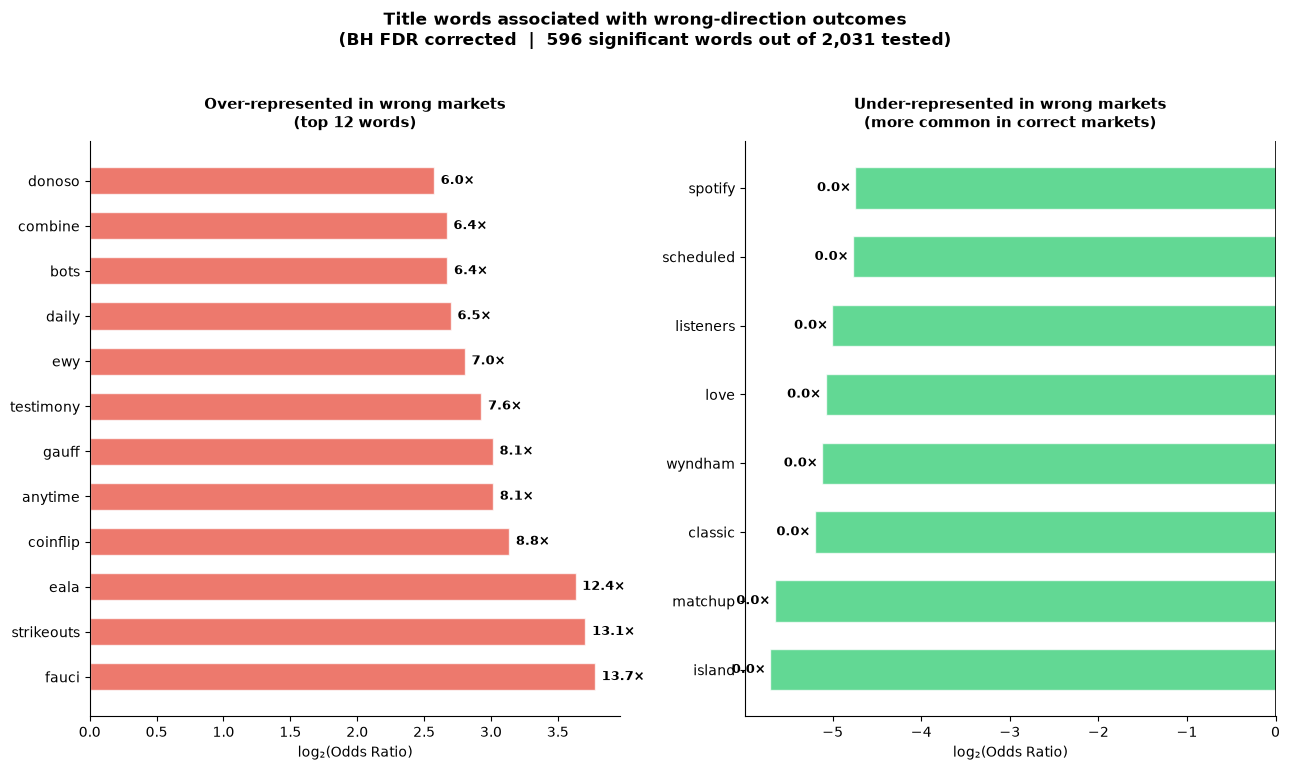

596 words significant after BH FDR.
Verdict: EXPLORATORY ASSOCIATION — these words associate with wrong-direction outcomes in observed data; causal mechanism unknown.


In [11]:
import re
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

_stop = {
    'the','a','an','in','on','at','to','of','and','or','is','be','will',
    'by','for','from','with','that','this','it','as','are','was','has',
    'have','do','does','not','no','if','but','can','its','which','who',
    'they','their','than','been','would','could','he','she','we','you',
    'i','my','your','our','his','her','new','per','about','into',
    '2024','2025','2026','january','february','march','april','may',
    'june','july','august','september','october','november','december',
}

def _tok(text):
    return [w for w in re.findall(r'[a-z]+', str(text).lower())
            if len(w) > 2 and w not in _stop]

_ws = Counter(w for t in grp_salah['title'].dropna() for w in _tok(t))
_wb = Counter(w for t in grp_benar['title'].dropna() for w in _tok(t))
_Ns, _Nb = len(grp_salah), len(grp_benar)

_rows = []
for w in set(_ws) | set(_wb):
    ns, nb = _ws.get(w, 0), _wb.get(w, 0)
    if ns + nb < 30:
        continue
    ct = np.array([[ns, _Ns-ns], [nb, _Nb-nb]])
    if ct.min() < 5:
        _, p = fisher_exact(ct)
    else:
        _, p, _, _ = chi2_contingency(ct)
    denom = (nb / (_Nb - nb)) if (_Nb - nb) > 0 and nb > 0 else np.nan
    numer = (ns / (_Ns - ns)) if (_Ns - ns) > 0 and ns > 0 else np.nan
    or_ = numer / denom if (denom and numer) else np.nan
    _rows.append({'word': w, 'n_s': ns, 'n_b': nb, 'OR': or_, 'p': p})

_kdf = pd.DataFrame(_rows).dropna(subset=['OR'])
_, _p_adj, _, _ = multipletests(_kdf['p'], method='fdr_bh')
_kdf['p_adj'] = _p_adj
_kdf['sig']   = _p_adj < 0.05

_sig  = _kdf[_kdf['sig']].copy()
_enr  = _sig[_sig['OR'] > 1].nlargest(12, 'OR')    # over-represented in wrong
_dep  = _sig[_sig['OR'] < 1].nsmallest(8, 'OR')    # under-represented (correct)

if len(_sig) == 0:
    print('No words significant after BH FDR correction (α=0.05).')
    print('Verdict: EXPLORATORY ASSOCIATION — no keyword survives correction.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, max(5, max(len(_enr), len(_dep))*0.5 + 1.5)))

    for ax, _sub, title, color, sign in [
        (axes[0], _enr, f'Over-represented in wrong markets\n(top {len(_enr)} words)', '#e74c3c', 1),
        (axes[1], _dep, f'Under-represented in wrong markets\n(more common in correct markets)', '#2ecc71', -1),
    ]:
        if len(_sub) == 0:
            ax.text(0.5, 0.5, 'None', ha='center', va='center', fontsize=12)
            ax.set_title(title, fontsize=11, fontweight='bold')
            continue
        _vals = np.log2(_sub['OR'].values)
        _words = _sub['word'].values
        _y = np.arange(len(_words))
        ax.barh(_y, _vals, color=color, alpha=0.75, edgecolor='white', height=0.6)
        ax.axvline(0, color='black', linewidth=1.2)
        for yi, (v, w, row) in enumerate(zip(_vals, _words, _sub.itertuples())):
            ax.text(v + sign*0.05, yi,
                    f"{row.OR:.1f}×", va='center',
                    ha='left' if sign > 0 else 'right', fontsize=9, fontweight='bold')
        ax.set_yticks(_y)
        ax.set_yticklabels(_words, fontsize=10)
        ax.set_xlabel('log₂(Odds Ratio)', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    fig.suptitle(f'Title words associated with wrong-direction outcomes\n'
                 f'(BH FDR corrected  |  {len(_sig):,} significant words out of {len(_kdf):,} tested)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS / 'plot12_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{len(_sig)} words significant after BH FDR.")
    print("Verdict: EXPLORATORY ASSOCIATION — these words associate with wrong-direction outcomes "
          "in observed data; causal mechanism unknown.")


### Characteristic 7 — Market Duration

> Are longer-open markets more accurate — because they receive more information? Or the opposite?

**Method:** Mann–Whitney U (two-sided) — duration is heavily skewed (Manifold: days, Polymarket: months), rank-based analysis
**Decision:** p < 0.05 → duration is associated with accuracy · p ≥ 0.05 → how long a market runs does not differentiate

In [12]:
_r = grp_benar['duration_sec'].dropna()
_w = grp_salah['duration_sec'].dropna()

if min(len(_r), len(_w)) < 50:
    print("Duration data insufficient. Skipping.")
else:
    _r, _w = _r[_r > 0].values, _w[_w > 0].values
    stat, p = mannwhitneyu(_r, _w, alternative='two-sided')
    r_rb = 1 - (2 * stat) / (len(_r) * len(_w))

    display(pd.DataFrame([
        {'Group': 'Correct direction', 'n': len(_r), 'Median duration': f'{np.median(_r)/86400:.0f} days'},
        {'Group': 'Wrong direction',   'n': len(_w), 'Median duration': f'{np.median(_w)/86400:.0f} days'},
    ]).style.hide(axis='index').set_caption('Characteristic 7 — Market Duration'))

    print(f"Mann–Whitney U  p {'<0.001' if p < 0.001 else f'={p:.4f}'}")
    print(f"Rank-biserial r = {r_rb:.3f}  ({'large' if abs(r_rb)>=0.5 else 'medium' if abs(r_rb)>=0.3 else 'small'} effect)")
    print(f"Verdict: {'STATISTICALLY SUPPORTED DIFFERENCE' if p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'}")


Group,n,Median duration
Correct direction,27589,49 days
Wrong direction,2249,8 days


Mann–Whitney U  p <0.001
Rank-biserial r = -0.325  (medium effect)
Verdict: STATISTICALLY SUPPORTED DIFFERENCE


### Characteristic 8 — Error Direction: YES Bias vs NO Bias

> Does the crowd say YES more often — both when right and when wrong? If so, that is systematic YES bias, not just noise.

> If the crowd has systematic YES bias: in the **wrong** group → dominant YES→NO · in the **correct** group → dominant YES→YES. Both patterns consistent = optimism bias, not coincidence.

**Method:** Binomial test separately per group (H₀: 50/50, two-sided)
**Decision:** both p < 0.05 and > 50% → systematic YES bias · only one → partial · neither → balanced distribution

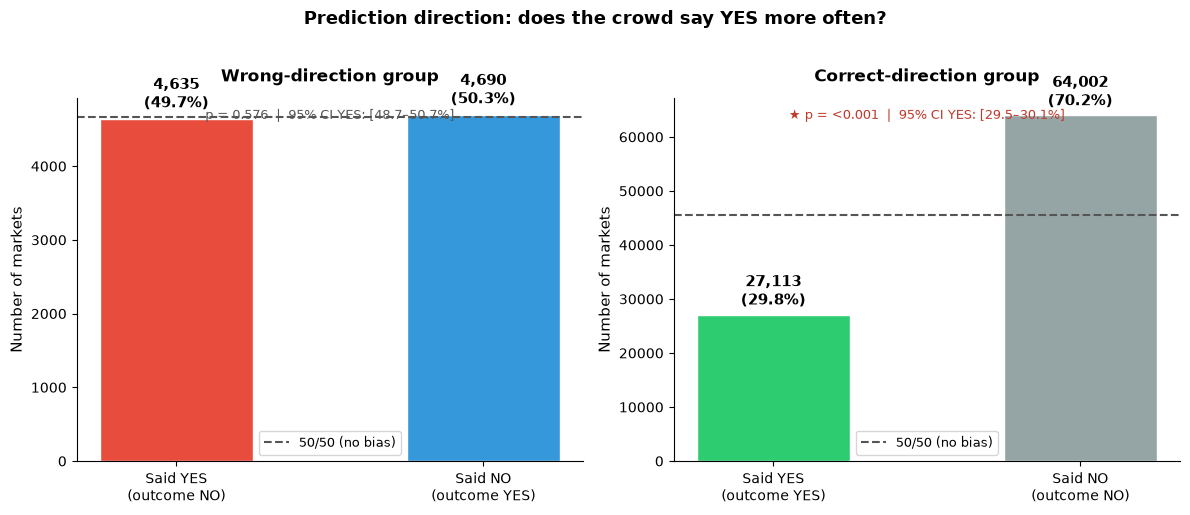

Wrong-direction group (9,325 markets):
  YES→NO : 4,635 (49.7%)  |  NO→YES: 4,690 (50.3%)
  Binomial p = 0.576  |  95% CI: [48.7%, 50.7%]

Correct-direction group (91,115 markets):
  YES→YES: 27,113 (29.8%)  |  NO→NO: 64,002 (70.2%)
  Binomial p = <0.001  |  95% CI: [29.5%, 30.1%]
Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE OF DIFFERENCE


In [13]:
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

# ── Kelompok SALAH: YES→NO vs NO→YES ─────────────────────────────────────
_wrong = study[study['salah']].copy()
_n_yw = int((_wrong['consensus_yes'] & (_wrong['outcome_bin'] == 0)).sum())
_n_nw = int((~_wrong['consensus_yes'] & (_wrong['outcome_bin'] == 1)).sum())
_tot_w = _n_yw + _n_nw
_bt_w = binomtest(_n_yw, _tot_w, p=0.5, alternative='two-sided')
_pct_yw = _n_yw / _tot_w
_lo_w, _hi_w = proportion_confint(_n_yw, _tot_w, method='wilson')

# ── Kelompok BENAR: YES→YES vs NO→NO ─────────────────────────────────────
_correct = study[~study['salah']].copy()
_n_yc = int((_correct['consensus_yes'] & (_correct['outcome_bin'] == 1)).sum())
_n_nc = int((~_correct['consensus_yes'] & (_correct['outcome_bin'] == 0)).sum())
_tot_c = _n_yc + _n_nc
_bt_c = binomtest(_n_yc, _tot_c, p=0.5, alternative='two-sided')
_pct_yc = _n_yc / _tot_c
_lo_c, _hi_c = proportion_confint(_n_yc, _tot_c, method='wilson')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_groups = [
    (_n_yw, _n_nw, _tot_w, _bt_w, _pct_yw, _lo_w, _hi_w,
     'Wrong-direction group', 'Said YES\n(outcome NO)', 'Said NO\n(outcome YES)',
     '#e74c3c', '#3498db'),
    (_n_yc, _n_nc, _tot_c, _bt_c, _pct_yc, _lo_c, _hi_c,
     'Correct-direction group', 'Said YES\n(outcome YES)', 'Said NO\n(outcome NO)',
     '#2ecc71', '#95a5a6'),
]

for ax, (n_yes, n_no, tot, bt, pct_y, lo, hi, group, lbl_yes, lbl_no, c_yes, c_no) in zip(axes, _groups):
    _heights = [n_yes, n_no]
    _lbls = [lbl_yes, lbl_no]
    _bars = ax.bar(_lbls, _heights, color=[c_yes, c_no], edgecolor='white', width=0.5)
    for bar, v in zip(_bars, _heights):
        ax.text(bar.get_x() + bar.get_width()/2, v + tot*0.01,
                f'{v:,}\n({v/tot*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.axhline(tot/2, color='#555', linewidth=1.5, linestyle='--', label='50/50 (no bias)')
    ax.set_ylabel('Number of markets', fontsize=11)
    ax.set_title(group, fontsize=12, fontweight='bold', pad=12)
    ax.legend(fontsize=9)
    _sig = bt.pvalue < 0.05
    _star = '★ ' if _sig else ''
    ax.text(0.5, 0.97,
            f'{_star}p = {fmt_p(bt.pvalue)}  |  95% CI YES: [{lo*100:.1f}–{hi*100:.1f}%]',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            color='#c0392b' if _sig else '#555')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Prediction direction: does the crowd say YES more often?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'plot_outcome_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Wrong-direction group ({_tot_w:,} markets):")
print(f"  YES→NO : {_n_yw:,} ({_pct_yw*100:.1f}%)  |  NO→YES: {_n_nw:,} ({(1-_pct_yw)*100:.1f}%)")
print(f"  Binomial p = {fmt_p(_bt_w.pvalue)}  |  95% CI: [{_lo_w*100:.1f}%, {_hi_w*100:.1f}%]")
print()
print(f"Correct-direction group ({_tot_c:,} markets):")
print(f"  YES→YES: {_n_yc:,} ({_pct_yc*100:.1f}%)  |  NO→NO: {_n_nc:,} ({(1-_pct_yc)*100:.1f}%)")
print(f"  Binomial p = {fmt_p(_bt_c.pvalue)}  |  95% CI: [{_lo_c*100:.1f}%, {_hi_c*100:.1f}%]")
if _bt_w.pvalue < 0.05 and _bt_c.pvalue < 0.05 and _pct_yw > 0.5 and _pct_yc > 0.5:
    print("Verdict: STATISTICALLY SUPPORTED — systematic YES bias in both groups")
elif _bt_w.pvalue < 0.05:
    _dir = 'YES bias' if _pct_yw > 0.5 else 'NO bias'
    print(f"Verdict: STATISTICALLY SUPPORTED — {_dir} in wrong group; correct group not significant")
else:
    print("Verdict: NO STATISTICALLY SIGNIFICANT EVIDENCE OF DIFFERENCE")


---
## Section VI — Which Characteristics Matter Simultaneously?

Section V tested each characteristic in isolation. The problem: correlated predictors produce ambiguous results — a significant univariate association might simply reflect that the predictor moves together with confidence.

Logistic regression estimates the **partial effect** of each predictor — its association with wrong-direction outcomes that persists with all others simultaneously in the model. Every predictor appears in the forest plot; there is nothing "held fixed." Each OR is just that predictor's estimated contribution after the model accounts for the others varying naturally in the data.

> **Model:** logistic regression → P(wrong) ~ confidence + platform + log(volume) + ...
> **Output:** Odds Ratio (OR) per predictor — from the forest plot
>
> **OR = exp(β), not the coefficient itself.** The logistic coefficient β measures change in log-odds — not intuitive. exp(β) gives the Odds Ratio: OR = 1.5 means 50% higher odds of wrong direction per one-unit increase in that predictor, estimated while all other predictors vary in the data simultaneously.
>
> **Each predictor gets its own OR** — including volume, duration, and platform. These are not "controls" in the sense of being held constant; they are co-estimated predictors. Volume OR = 1.09 is volume's partial effect on wrong-direction odds, with the model simultaneously accounting for variation in confidence, duration, and platform.
>
> *Only predictors with ≥ 1,000 markets in ≥ 2 platforms included — to avoid unstable estimates.*

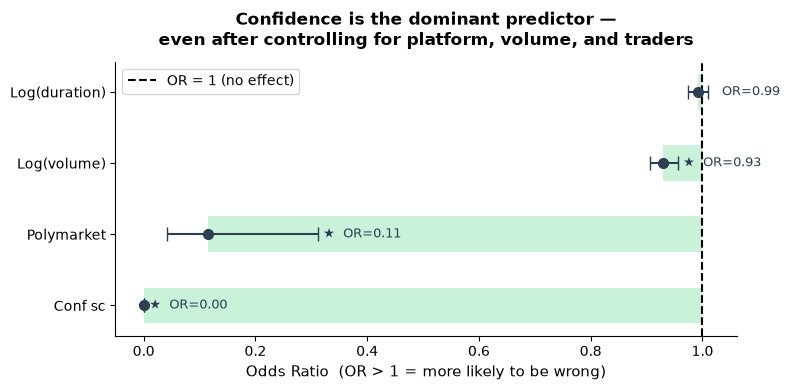

N=29,765  |  Pseudo-R² (McFadden)=0.3541
Predictors: ['conf_sc', 'C(platform)', 'log_volume', 'log_duration']


In [14]:
import statsmodels.formula.api as smf

_reg = study.copy()
_reg['salah_int'] = _reg['salah'].astype(int)
_reg['conf_sc']   = _reg['conf']

for _raw, _log in [('num_traders','log_traders'),
                   ('volume_usd', 'log_volume'),
                   ('duration_sec','log_duration')]:
    _reg[_log] = np.log1p(_reg[_raw].clip(lower=0)) if _raw in _reg.columns else np.nan

# Build predictors incrementally: only add a column if the intersection
# after dropna still leaves ≥1000 rows (avoids zero-row dataset → patsy crash)
_needed = ['salah_int', 'conf_sc', 'platform']
_rhs    = ['conf_sc', 'C(platform)']
for _col, _part in [('log_volume','log_volume'),
                    ('log_traders','log_traders'),
                    ('log_duration','log_duration')]:
    if _col not in _reg.columns:
        continue
    _test = _reg[_needed + [_col]].dropna()
    _test = _test[_test['platform'].map(_test['platform'].value_counts()) > 10]
    if len(_test) >= 1000 and _test['platform'].nunique() >= 2:
        _needed.append(_col); _rhs.append(_part)

_rc = _reg[_needed].dropna()
_rc = _rc[_rc['platform'].map(_rc['platform'].value_counts()) > 10]
_rc['platform'] = _rc['platform'].astype('category')

try:
    if len(_rc) < 50 or _rc['platform'].nunique() < 2:
        print(f'Data tidak cukup untuk regresi (N={len(_rc)}, platforms={_rc["platform"].nunique()})')
    else:
        _model = smf.logit('salah_int ~ ' + ' + '.join(_rhs), data=_rc).fit(disp=False)
        _or = pd.DataFrame({
            'var': _model.params.index,
            'OR':  np.exp(_model.params),
            'lo':  np.exp(_model.conf_int()[0]),
            'hi':  np.exp(_model.conf_int()[1]),
            'p':   _model.pvalues,
        })
        _or = _or[_or['var'] != 'Intercept'].copy()
        _or['label'] = (_or['var']
                        .str.replace(r'C\(platform\)\[T\.', '', regex=True)
                        .str.replace(']', '', regex=False)
                        .str.replace('_', ' ', regex=False)
                        .str.replace('log ', 'log(', regex=False)
                        .str.capitalize()
                        + _or['var'].str.contains('log').map({True:')', False:''}))
        _or['sig'] = _or['p'] < 0.05
        _or = _or.sort_values('OR', ascending=True).reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(8, max(4, len(_or) * 0.6 + 1)))
        _y  = np.arange(len(_or))
        _clrs = ['#e74c3c' if or_ > 1 else '#2ecc71' for or_ in _or['OR']]

        ax.barh(_y, _or['OR'] - 1, left=1, color=_clrs, alpha=0.25, height=0.5)
        ax.errorbar(_or['OR'], _y,
                    xerr=[(_or['OR'] - _or['lo']).clip(lower=0),
                           (_or['hi'] - _or['OR']).clip(lower=0)],
                    fmt='o', color='#2c3e50', capsize=5,
                    linewidth=1.5, markersize=7, zorder=4)
        for i, (_, row) in enumerate(_or.iterrows()):
            ax.text(max(row['OR'], row['hi']) + 0.01, i,
                    f"{'★' if row['sig'] else ''}  OR={row['OR']:.2f}",
                    va='center', fontsize=9,
                    color='#c0392b' if row['sig'] and row['OR'] > 1 else '#2c3e50')

        ax.axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (no effect)')
        ax.set_yticks(_y)
        ax.set_yticklabels(_or['label'], fontsize=10)
        ax.set_xlabel('Odds Ratio  (OR > 1 = more likely to be wrong)', fontsize=11)
        ax.set_title('Confidence is the dominant predictor —\neven after controlling for platform, volume, and traders',
                     fontsize=12, fontweight='bold', pad=12)
        ax.legend(fontsize=10)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()
        plt.savefig(FIGS / 'plot09_regression.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"N={len(_rc):,}  |  Pseudo-R² (McFadden)={_model.prsquared:.4f}")
        print(f"Predictors: {_rhs}")

except Exception as _e:
    import traceback
    print(f'Regresi gagal: {_e}')
    traceback.print_exc()


**Reading the forest plot:**

Each row is one predictor. The **dot** = OR, the **bar** = 95% CI.

> **Check the CI first.** If the bar includes 1 (touches the dashed line) → no statistically detectable effect, the OR is unreliable. If the bar clears 1 on both sides → the OR is meaningful.

| CI clears 1, OR < 1 | Associated with lower wrong-direction odds |
|---|---|
| CI clears 1, OR > 1 | Associated with higher wrong-direction odds |
| CI includes 1 | No detectable partial effect in this model |

A predictor that was significant in Section V can lose significance here — not because it stopped mattering, but because its variation overlaps with confidence, and the model assigns the shared variance to the stronger predictor.

Confidence is the **dominant predictor** of directional failure — even after
accounting for platform, volume, and other characteristics.
Other variables contribute marginally once confidence is controlled.

---
## Summary — The Market Profile

### Evidence table

Every characteristic comparison receives an explicit statistical verdict.
Numbers come from the analyses above.

In [15]:
# ── Final: Evidence summary table ─────────────────────────────────────────────
from IPython.display import display
from scipy.stats import mannwhitneyu

_rows = [
    ['Confidence (|p−0.5|)',
     f'{np.median(grp_benar["conf"]):.3f}',
     f'{np.median(grp_salah["conf"]):.3f}',
     'Mann–Whitney U', '—', 'STATISTICALLY SUPPORTED DIFFERENCE'],
]

for _label, _rc, _rw in [
    ('Trader count',        grp_benar['num_traders'].dropna(), grp_salah['num_traders'].dropna()),
    ('Trading volume (USD)', grp_benar['volume_usd'].dropna(),  grp_salah['volume_usd'].dropna()),
    ('Market duration (sec)', grp_benar['duration_sec'].dropna(), grp_salah['duration_sec'].dropna()),
]:
    if min(len(_rc), len(_rw)) < 50:
        continue
    _s, _p = mannwhitneyu(_rc, _rw, alternative='two-sided')
    _r = 1 - (2*_s)/(len(_rc)*len(_rw))
    _v = 'STATISTICALLY SUPPORTED DIFFERENCE' if _p < 0.05 else 'NO EVIDENCE OF DIFFERENCE'
    if _label == 'Trader count':
        _rows.append([_label, f'{np.median(_rc):.0f}', f'{np.median(_rw):.0f}',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])
    elif _label == 'Trading volume (USD)':
        _rows.append([_label, f'${np.median(_rc):,.0f}', f'${np.median(_rw):,.0f}',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])
    else:  # duration
        _rows.append(['Market duration',
                      f'{np.median(_rc)/86400:.0f} days', f'{np.median(_rw)/86400:.0f} days',
                      'Mann–Whitney U', f'r={_r:.2f}', _v])

_tbl = pd.DataFrame(_rows, columns=[
    'Characteristic', 'Correct (median/composition)', 'Wrong (median/composition)',
    'Test', 'Effect size', 'Verdict'])

display(_tbl.style
        .hide(axis='index')
        .set_caption('Market Profile: Correct vs Wrong-Direction Markets')
        .map(lambda v: 'color: #27ae60; font-weight: bold'
             if 'SUPPORTED' in str(v)
             else ('color: #e74c3c' if 'NO EVIDENCE' in str(v) else '')))


Characteristic,Correct (median/composition),Wrong (median/composition),Test,Effect size,Verdict
Confidence (|p−0.5|),0.490,0.085,Mann–Whitney U,—,STATISTICALLY SUPPORTED DIFFERENCE
Trader count,11,7,Mann–Whitney U,r=-0.26,STATISTICALLY SUPPORTED DIFFERENCE
Trading volume (USD),"$3,652","$2,687",Mann–Whitney U,r=-0.06,STATISTICALLY SUPPORTED DIFFERENCE
Market duration,49 days,8 days,Mann–Whitney U,r=-0.33,STATISTICALLY SUPPORTED DIFFERENCE


In [16]:
# ── Sidenote: Title keyword associations (exploratory) ────────────────────────
# n = number of markets whose title contains that keyword (not word-occurrence count)
from scipy.stats import fisher_exact

def _kw_row(kw, label, wrong_titles, correct_titles):
    _wt = wrong_titles.dropna()
    _ct = correct_titles.dropna()
    n_w, n_c = len(_wt), len(_ct)
    a = sum(1 for t in _wt if kw in str(t).lower())
    b = sum(1 for t in _ct if kw in str(t).lower())
    if b == 0 or (n_w - a) == 0:
        return None
    c_, d = n_w - a, n_c - b
    OR = (a * d) / (b * c_)
    return [label, a, b, f'{OR:.2f}']

_kw_rows = []
_wt_s, _ct_s = grp_salah['title'], grp_benar['title']

# Wrong-direction keywords (OR >> 1: more common in wrong markets)
for _kw, _lbl in [('coinflip', '"coinflip"'), ('anytime', '"anytime"'), ('daily', '"daily"')]:
    _r = _kw_row(_kw, _lbl, _wt_s, _ct_s)
    if _r:
        _kw_rows.append(_r + ['↑ wrong-direction'])

# Correct-direction keywords (OR << 1: more common in correct markets)
for _kw, _lbl in [('win', '"win"'), ('champion', '"champion"'), ('season', '"season"')]:
    _r = _kw_row(_kw, _lbl, _wt_s, _ct_s)
    if _r:
        _kw_rows.append(_r + ['↑ correct-direction'])

_kw_tbl = pd.DataFrame(_kw_rows, columns=[
    'Keyword', 'Markets (wrong)', 'Markets (correct)', 'OR', 'Association'])

display(_kw_tbl.style
        .hide(axis='index')
        .set_caption('Sidenote — Title Keyword Associations (exploratory, Fisher exact)')
        .map(lambda v: 'color: #c0392b' if '↑ wrong' in str(v)
             else ('color: #27ae60' if '↑ correct' in str(v) else ''),
             subset=['Association']))


Keyword,Markets (wrong),Markets (correct),OR,Association
"""coinflip""",222,252,8.79,↑ wrong-direction
"""anytime""",56,68,8.09,↑ wrong-direction
"""daily""",247,379,6.51,↑ wrong-direction
"""win""",894,16193,0.49,↑ correct-direction
"""champion""",157,3773,0.40,↑ correct-direction
"""season""",38,2730,0.13,↑ correct-direction


---
### Why category and error direction were excluded from the table

**Category** — some categories have a higher wrong-direction rate, but higher rate is not the same as a reliable label. A category with 45% wrong rate still produces 55% correct markets. It's like "teenage drivers have more accidents" — true on average, useless for judging any one driver.

**Error direction (YES bias)** — p = 0.576. Among wrong-direction markets, YES→NO and NO→YES failures were roughly equal. No systematic directional bias in which way markets fail.

---
## Conclusion

**Confidence → reliability**: the further the price from 50%, the more often the crowd is right.